#Introduction

This project develops and evaluates machine learning models to predict whether a patient is likely to have diabetes based on clinical and demographic data. The goal is to compare multiple classification algorithms and identify the model that provides the best predictive performance while following machine learning best practices.

#1. Import Libraries

In [1]:
pip install kagglehub[pandas-datasets]

In [2]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, mean_absolute_error, roc_auc_score, RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

#2. Load Dataset

In [3]:
file_path = "diabetes.csv"
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "uciml/pima-indians-diabetes-database", file_path)

print(df.head(10))

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   
8            2      197             70             45      543  30.5   
9            8      125             96              0        0   0.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31  

In [4]:
print(df.shape)
print('_' * 40)
print(df.info())
print('_' * 40)
print(df.describe())

(768, 9)
________________________________________
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
________________________________________
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.00

#3. Exploratory Data Analysis

In [5]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [6]:
df.duplicated().sum()

np.int64(0)

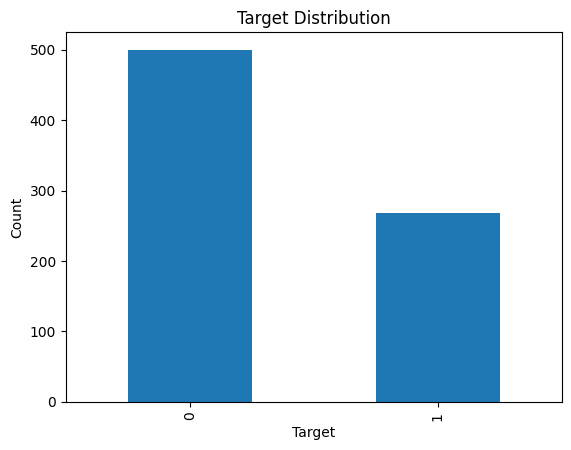

In [7]:
df["Outcome"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Target Distribution")

plt.show()

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

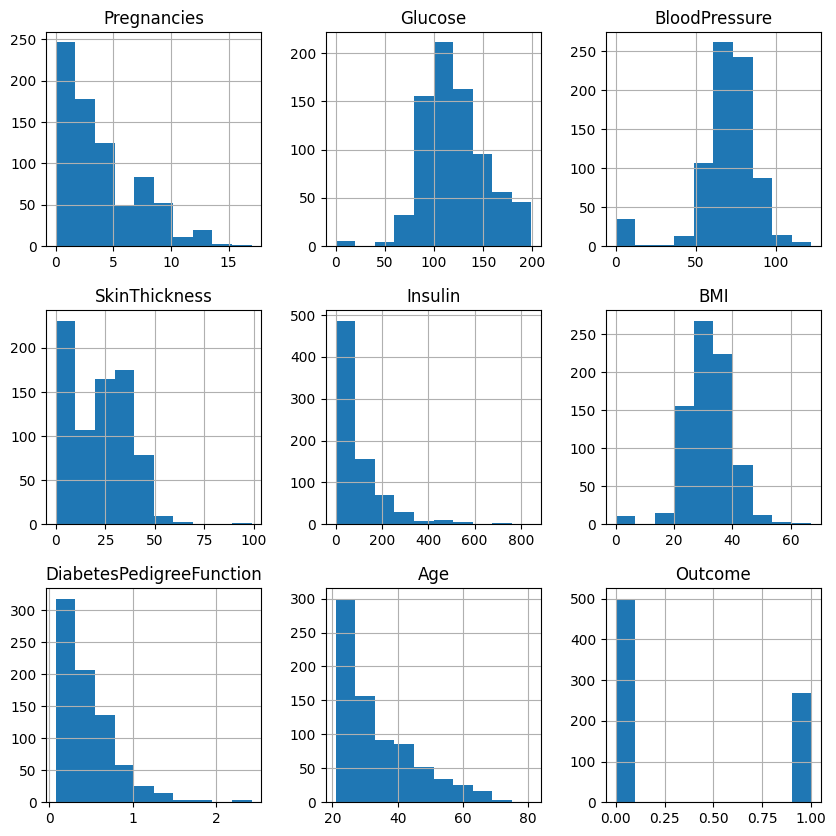

In [8]:
df.hist(figsize = (10,10))

<Axes: >

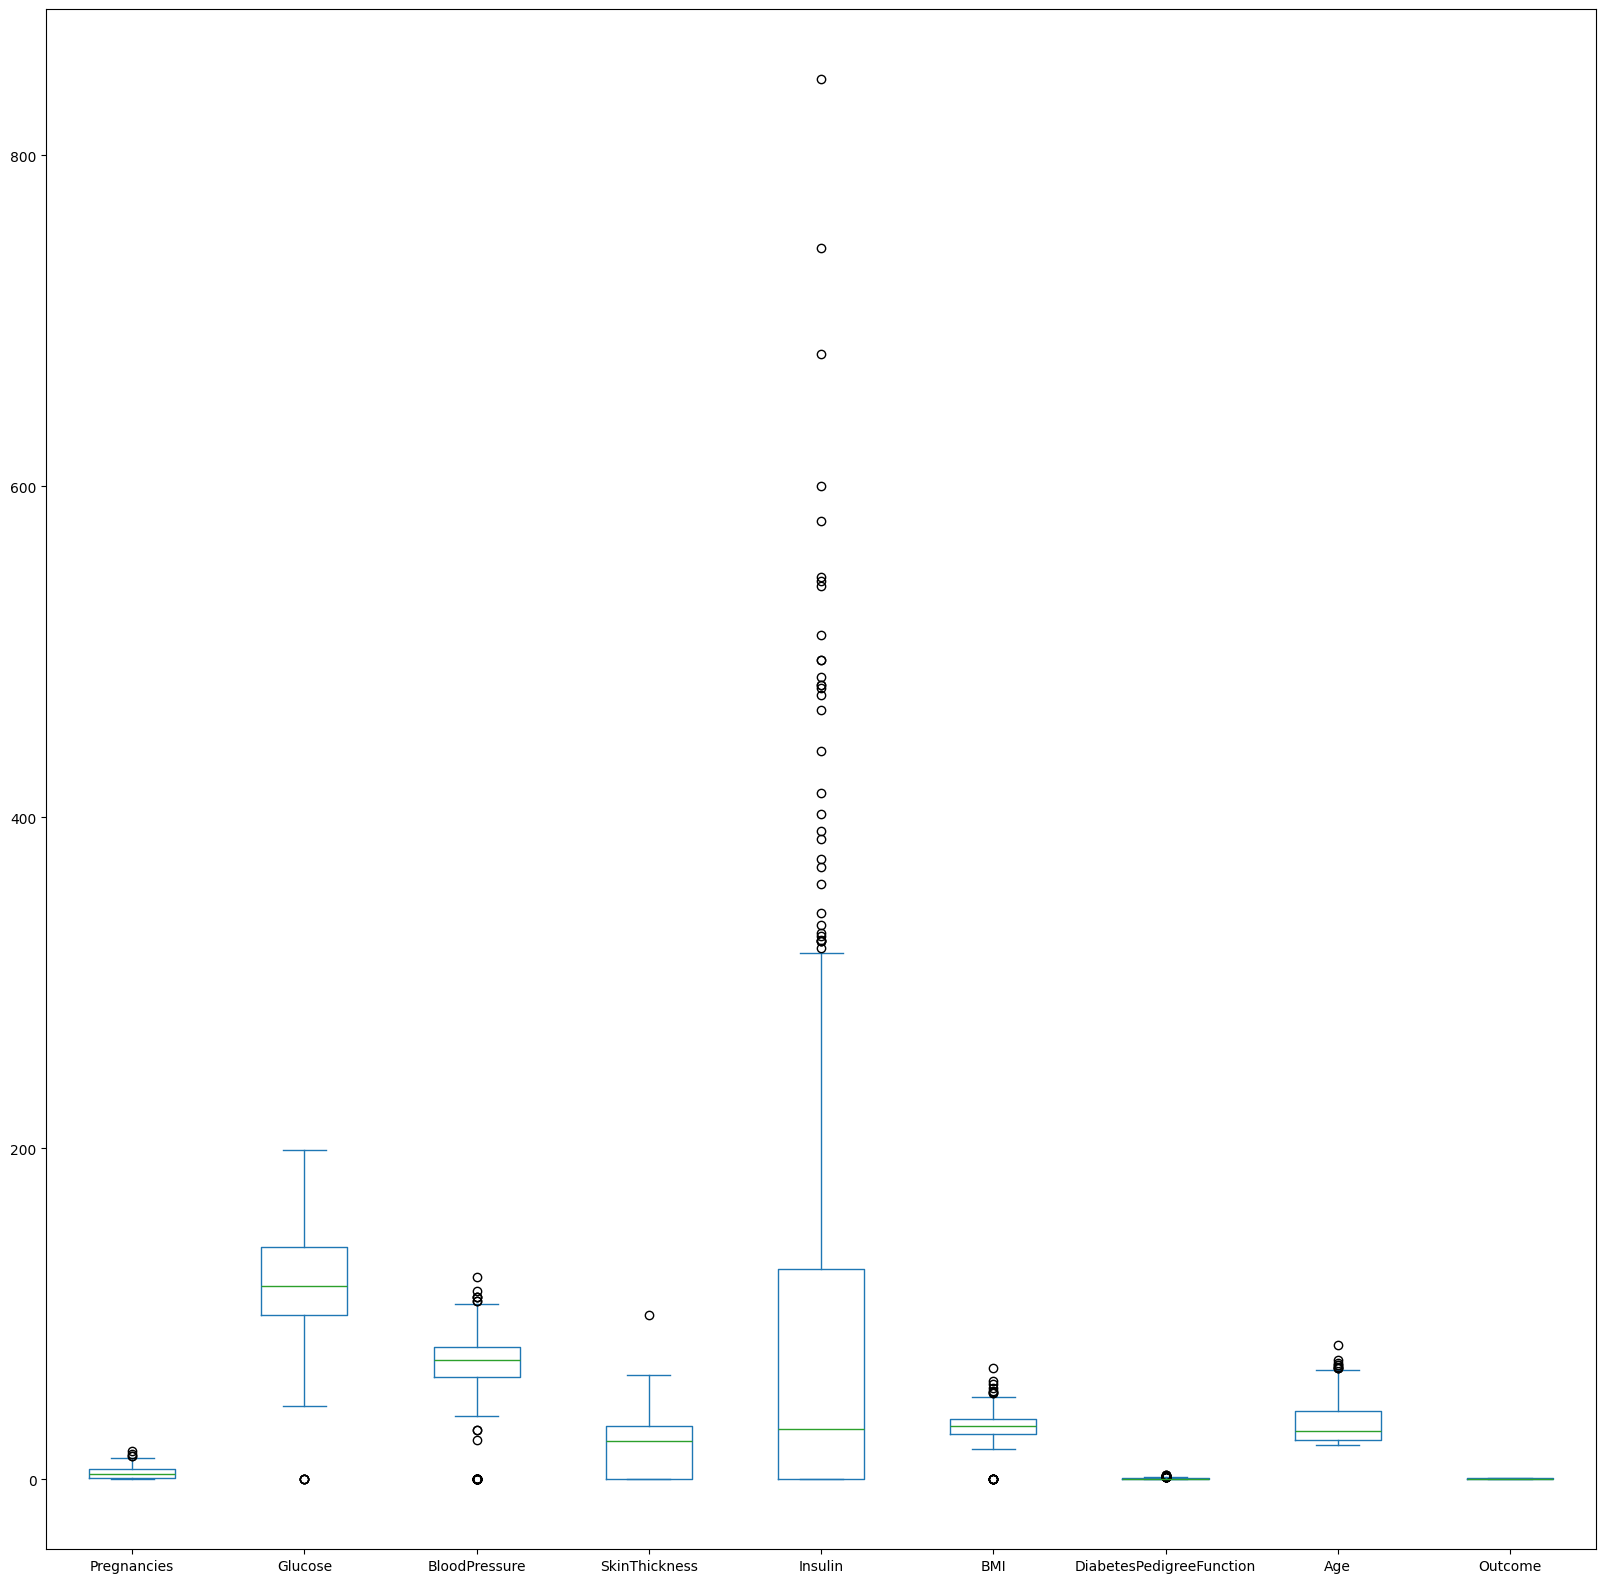

In [9]:
df.plot.box(figsize = (20,20))

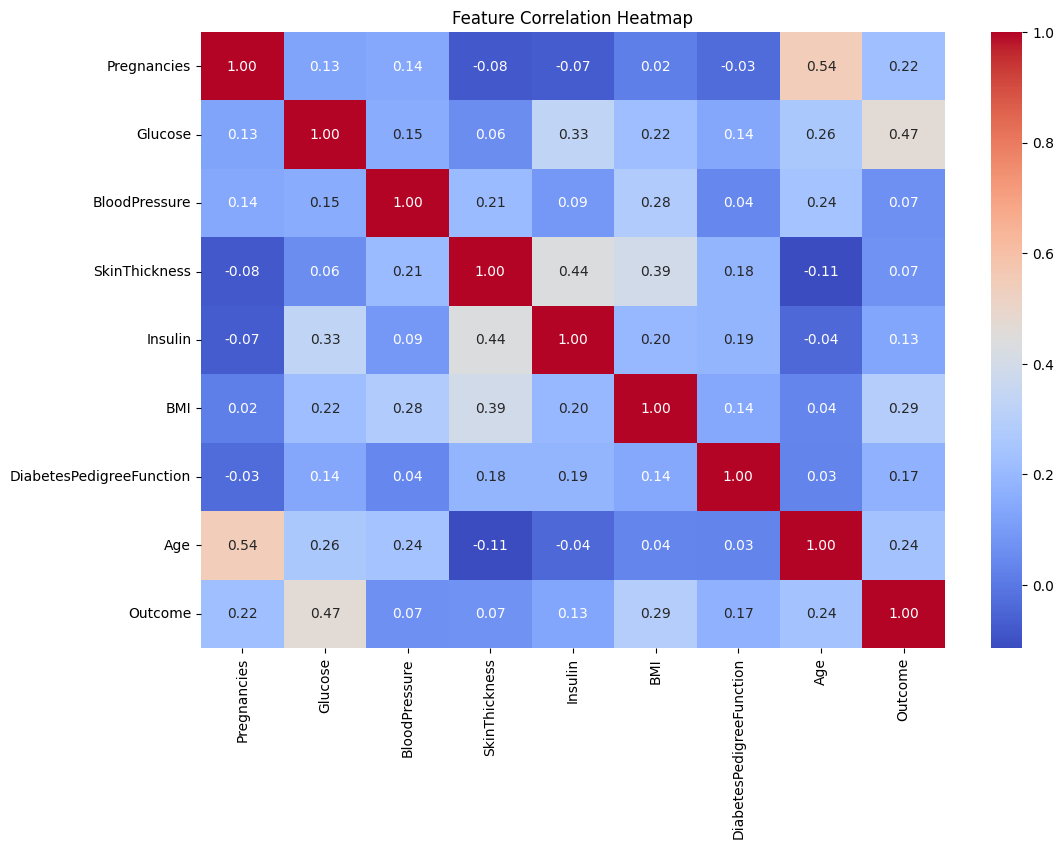

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")

plt.show()

#4. Data Cleaning

In [11]:
dataset = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for data in dataset:
  df[data] = df[data].replace(0, np.nan)
df = df.astype(float)
#df = df.fillna(df.mean())

In [12]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#5. Feature Engineering

In [13]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 0   # Underweight
    elif bmi < 25:
        return 1   # Normal
    elif bmi < 30:
        return 2   # Overweight
    else:
        return 3   # Obese

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [14]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[20,30,40,50,60,100],
    labels=False
)

In [15]:
print(df.head(10))

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0      NaN  33.6   
1          1.0     85.0           66.0           29.0      NaN  26.6   
2          8.0    183.0           64.0            NaN      NaN  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   
5          5.0    116.0           74.0            NaN      NaN  25.6   
6          3.0     78.0           50.0           32.0     88.0  31.0   
7         10.0    115.0            NaN            NaN      NaN  35.3   
8          2.0    197.0           70.0           45.0    543.0  30.5   
9          8.0    125.0           96.0            NaN      NaN   NaN   

   DiabetesPedigreeFunction   Age  Outcome  BMI_Category  Age_Group  
0                     0.627  50.0      1.0             3          2  
1                     0.351  31.0      0.0             2          1

#6. Train/Test Split

In [16]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

#7. Model Training

In [17]:
models = []

lr_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=random_state))])
models.append(("Linear Regression", lr_pipeline))
dt_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", DecisionTreeClassifier(max_depth=10, random_state=random_state))])
models.append(("Decision Tree", dt_pipeline))
rf_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(max_depth=None, n_estimators=200, random_state=random_state))])
models.append(("Random Forest", rf_pipeline))
svm_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", SVC(kernel="rbf", probability=True, random_state=random_state))])
models.append(("SVM RBF", svm_pipeline))
knn_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=3))])
models.append(("K-NN", knn_pipeline))

In [18]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    }

results = []
for name, model in models:
    results.append(evaluate_model(name, model))

print(pd.DataFrame(results))

               Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Linear Regression  0.753247   0.660377  0.636364  0.648148  0.814692
1      Decision Tree  0.733766   0.606061  0.727273  0.661157  0.738108
2      Random Forest  0.753247   0.639344  0.709091  0.672414  0.831221
3            SVM RBF  0.733766   0.640000  0.581818  0.609524  0.803122
4               K-NN  0.694805   0.564516  0.636364  0.598291  0.753627


In [19]:
best_model = rf_pipeline

#8. Model Comparison

In [20]:
print("Confusion Matrix:\n", confusion_matrix(y_test, best_model.predict(X_test)))

Confusion Matrix:
 [[77 22]
 [16 39]]


In [21]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')

print(scores)
print("Mean Accuracy: %f (%f)" %(scores.mean(), scores.std()))

[0.81300813 0.7804878  0.74796748 0.7398374  0.80327869]
Mean Accuracy: 0.776916 (0.029063)


ROC-AUC: 0.8312213039485767


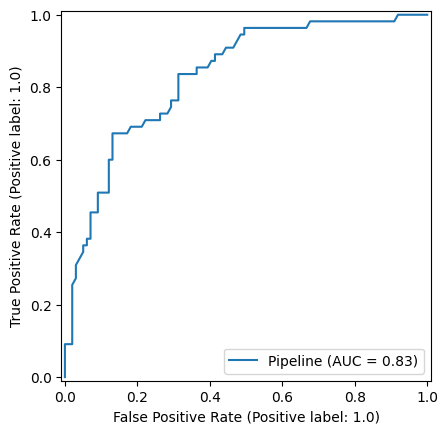

In [22]:
y_prob = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

#9. Hyperparameter Tuning

In [23]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_pipeline.named_steps['model'].feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                    Feature  Importance
1                   Glucose    0.250307
5                       BMI    0.142952
7                       Age    0.120208
6  DiabetesPedigreeFunction    0.111706
4                   Insulin    0.081346
2             BloodPressure    0.075257
3             SkinThickness    0.066949
0               Pregnancies    0.060880
9                 Age_Group    0.054033
8              BMI_Category    0.036362


In [24]:
features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction", "Insulin"]
X = df[features]
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [25]:
param_grid = {
    'model__n_estimators':[100,200,300],
    'model__max_depth':[5,10,20,None],
    'model__min_samples_split':[2,5,10],
    'model__min_samples_leaf':[1,2,4]
}

best_model = GridSearchCV(best_model, param_grid, cv=5, scoring='roc_auc')
best_model.fit(X_train, y_train)

print("Best Parameters:", best_model.best_params_)
print("Best Score:", best_model.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best Score: 0.8505814124386475


#10. Final Evaluation

In [26]:
print("Confusion Matrix:\n", confusion_matrix(y_test, best_model.predict(X_test)))
print("Classification Report:\n", classification_report(y_test, best_model.predict(X_test)))

scores = cross_val_score(best_model, X_train, y_train, cv=kfold, scoring='accuracy')
print(scores)
print("Cross Validation Score: %f (%f)" %(scores.mean(), scores.std()))

Confusion Matrix:
 [[79 20]
 [19 36]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.80      0.80        99
         1.0       0.64      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154

[0.78861789 0.7804878  0.73170732 0.71544715 0.80327869]
Cross Validation Score: 0.763908 (0.034120)


#Conclusion

Five classification models were evaluated for diabetes prediction. Random Forest achieved the highest ROC-AUC after hyperparameter tuning and was selected as the final model. Because diabetes screening prioritizes identifying positive cases, recall and ROC-AUC were considered alongside accuracy. Future work could include handling class imbalance with SMOTE and evaluating Gradient Boosting models.